# Комплексное решение задач эллиптических уравнений методом разделения переменных (v3)

**Решение задач №8, №9, №10, №11, №12 из третьей таблицы**

Каждая задача решена подробно по схеме из Примеров 4 и 5 методички (все 7 шагов) с пояснениями всех формул и численной визуализацией с 3D поверхностями $u(x,y)$ или $u(r,\theta)$.

**Версия v3: Полное решение всех задач с раздельными шагами и проверкой в Python**


## Задача №8 (Декартовы координаты)

**Дано:**
- **Уравнение:** $\Delta u = u_{xx} + u_{yy} = 0$
- **Область:** Прямоугольник $x \in [0,2], y \in [0,1]$
- **Граничные условия:**
  - $u|_{x=0} = 0$
  - $u|_{y=0} = 0$
  - $u|_{x=2} = 2\sin(3\pi y)$
  - $u|_{y=1} = 3\sin(\pi x)$


### Шаг 1. Приведение граничных условий к однородным

Для эллиптических уравнений с неоднородными граничными условиями на всех сторонах используем **принцип суперпозиции** (3-й подход из методички, Пример 3).

Представим решение в виде суммы двух подзадач:
$$u(x,y) = u_1(x,y) + u_2(x,y)$$

**Подзадача 1:** Решаем задачу с неоднородностью только на стороне $y=1$:
$$\begin{cases}
\Delta u_1 = 0 \\
u_1|_{x=0} = 0, \quad u_1|_{x=2} = 0 \\
u_1|_{y=0} = 0, \quad u_1|_{y=1} = 3\sin(\pi x)
\end{cases}$$

**Подзадача 2:** Решаем задачу с неоднородностью только на стороне $x=2$:
$$\begin{cases}
\Delta u_2 = 0 \\
u_2|_{x=0} = 0, \quad u_2|_{x=2} = 2\sin(3\pi y) \\
u_2|_{y=0} = 0, \quad u_2|_{y=1} = 0
\end{cases}$$

Тогда сумма $u = u_1 + u_2$ будет решением исходной задачи.


### Шаг 2. Пересчет уравнений для подзадач

Обе подзадачи имеют однородное уравнение Лапласа $\Delta u = 0$, поэтому пересчет не требуется.

**Подзадача 1:**
$$\begin{cases}
u_{1,xx} + u_{1,yy} = 0 \\
u_1(0,y) = 0, \quad u_1(2,y) = 0 \\
u_1(x,0) = 0, \quad u_1(x,1) = 3\sin(\pi x)
\end{cases}$$

**Подзадача 2:**
$$\begin{cases}
u_{2,xx} + u_{2,yy} = 0 \\
u_2(0,y) = 0, \quad u_2(2,y) = 2\sin(3\pi y) \\
u_2(x,0) = 0, \quad u_2(x,1) = 0
\end{cases}$$


### Шаг 3. Определение собственных функций и собственных значений

#### Подзадача 1:

Ищем решение в виде $u_1(x,y) = X(x) \cdot Y(y)$.

Подставляем в уравнение: $X''(x)Y(y) + X(x)Y''(y) = 0$

Разделяем переменные:
$$\frac{X''(x)}{X(x)} = -\frac{Y''(y)}{Y(y)} = -\lambda^2$$

Получаем два уравнения:
$$X''(x) + \lambda^2 X(x) = 0, \quad Y''(y) - \lambda^2 Y(y) = 0$$

Граничные условия:
- $X(0) = 0, \quad X(2) = 0$ (из $u_1(0,y) = 0, u_1(2,y) = 0$)
- $Y(0) = 0$ (из $u_1(x,0) = 0$)

Для $X(x)$: общее решение $X(x) = c_1 \sin\lambda x + c_2 \cos\lambda x$

Из $X(0) = 0$: $c_2 = 0$, следовательно $X(x) = c_1 \sin\lambda x$

Из $X(2) = 0$: $\sin(2\lambda) = 0 \Rightarrow 2\lambda = k\pi, \quad k = 1, 2, 3, \ldots$

**Собственные значения:** $\lambda_k = \frac{k\pi}{2}, \quad k = 1, 2, 3, \ldots$

**Собственные функции:** $X_k(x) = \sin\frac{k\pi x}{2}$

Для $Y(y)$: уравнение $Y''(y) - \lambda_k^2 Y(y) = 0$ с условием $Y(0) = 0$

Общее решение: $Y(y) = c_3 e^{\lambda_k y} + c_4 e^{-\lambda_k y} = c_5 \sinh(\lambda_k y) + c_6 \cosh(\lambda_k y)$

Из $Y(0) = 0$: $c_6 = 0$, следовательно $Y_k(y) = \sinh(\lambda_k y) = \sinh\frac{k\pi y}{2}$

**Решение подзадачи 1:**
$$u_1(x,y) = \sum_{k=1}^{\infty} A_k \sin\frac{k\pi x}{2} \sinh\frac{k\pi y}{2}$$


#### Подзадача 2:

Ищем решение в виде $u_2(x,y) = X(x) \cdot Y(y)$.

Граничные условия:
- $X(0) = 0$ (из $u_2(0,y) = 0$)
- $Y(0) = 0, \quad Y(1) = 0$ (из $u_2(x,0) = 0, u_2(x,1) = 0$)

Для $Y(y)$: $Y''(y) + \mu^2 Y(y) = 0$ с $Y(0) = Y(1) = 0$

Общее решение: $Y(y) = c_1 \sin\mu y + c_2 \cos\mu y$

Из $Y(0) = 0$: $c_2 = 0$, следовательно $Y(y) = c_1 \sin\mu y$

Из $Y(1) = 0$: $\sin\mu = 0 \Rightarrow \mu = k\pi, \quad k = 1, 2, 3, \ldots$

**Собственные значения:** $\mu_k = k\pi, \quad k = 1, 2, 3, \ldots$

**Собственные функции:** $Y_k(y) = \sin(k\pi y)$

Для $X(x)$: уравнение $X''(x) - \mu_k^2 X(x) = 0$ с условием $X(0) = 0$

Общее решение: $X(x) = c_3 e^{\mu_k x} + c_4 e^{-\mu_k x} = c_5 \sinh(\mu_k x) + c_6 \cosh(\mu_k x)$

Из $X(0) = 0$: $c_6 = 0$, следовательно $X_k(x) = \sinh(\mu_k x) = \sinh(k\pi x)$

**Решение подзадачи 2:**
$$u_2(x,y) = \sum_{k=1}^{\infty} C_k \sinh(k\pi x) \sin(k\pi y)$$


### Шаг 4. Разложение граничных условий в ряды Фурье

#### Подзадача 1:

Из граничного условия $u_1(x,1) = 3\sin(\pi x)$:
$$\sum_{k=1}^{\infty} A_k \sin\frac{k\pi x}{2} \sinh\frac{k\pi}{2} = 3\sin(\pi x)$$

Разложим $3\sin(\pi x)$ в ряд Фурье по системе $\left\{\sin\frac{k\pi x}{2}\right\}$:

Коэффициенты Фурье:
$$A_k \sinh\frac{k\pi}{2} = \frac{2}{2} \int_0^2 3\sin(\pi x) \sin\frac{k\pi x}{2} dx = 3 \int_0^2 \sin(\pi x) \sin\frac{k\pi x}{2} dx$$

Используя формулу произведения синусов:
$$\sin(\pi x) \sin\frac{k\pi x}{2} = \frac{1}{2}\left[\cos\left(\pi x - \frac{k\pi x}{2}\right) - \cos\left(\pi x + \frac{k\pi x}{2}\right)\right]$$

При $k=2$ (т.е. $\frac{k\pi}{2} = \pi$):
$$\int_0^2 \sin(\pi x) \sin(\pi x) dx = \int_0^2 \sin^2(\pi x) dx = 1$$

Следовательно:
$$A_2 \sinh\pi = 3 \cdot 1 = 3 \Rightarrow A_2 = \frac{3}{\sinh\pi}$$

Для остальных $k$: $A_k = 0$ (ортогональность).


#### Подзадача 2:

Из граничного условия $u_2(2,y) = 2\sin(3\pi y)$:
$$\sum_{k=1}^{\infty} C_k \sinh(k\pi \cdot 2) \sin(k\pi y) = 2\sin(3\pi y)$$

Так как $\sin(3\pi y)$ уже является собственной функцией при $k=3$:
$$C_3 \sinh(6\pi) = 2 \Rightarrow C_3 = \frac{2}{\sinh(6\pi)}$$

Для остальных $k$: $C_k = 0$.


### Шаг 5. Определение коэффициентов

**Подзадача 1:**
$$A_2 = \frac{3}{\sinh\pi}, \quad A_k = 0 \text{ для } k \neq 2$$

**Подзадача 2:**
$$C_3 = \frac{2}{\sinh(6\pi)}, \quad C_k = 0 \text{ для } k \neq 3$$


### Шаг 6. Запись полного решения

**Подзадача 1:**
$$u_1(x,y) = \frac{3}{\sinh\pi} \sin(\pi x) \sinh(\pi y)$$

**Подзадача 2:**
Для $k=3$: $\mu_3 = 3\pi$, поэтому $X_3(x) = \sinh(3\pi x)$
$$u_2(x,y) = \frac{2}{\sinh(6\pi)} \sinh(3\pi x) \sin(3\pi y)$$

**Полное решение:**
$$u(x,y) = u_1(x,y) + u_2(x,y) = \frac{3}{\sinh\pi} \sin(\pi x) \sinh(\pi y) + \frac{2}{\sinh(6\pi)} \sinh(3\pi x) \sin(3\pi y)$$


### Шаг 7. Окончательный ответ и проверка

**Ответ задачи №8:**
$$\boxed{u(x,y) = \frac{3}{\sinh\pi} \sin(\pi x) \sinh(\pi y) + \frac{2}{\sinh(6\pi)} \sinh(3\pi x) \sin(3\pi y)}$$

**Проверка граничных условий:**
- $u(0,y) = 0 + 0 = 0$ ✓
- $u(x,0) = 0 + 0 = 0$ ✓
- $u(2,y) = \frac{3}{\sinh\pi} \sin(2\pi) \sinh(\pi y) + \frac{2}{\sinh(6\pi)} \sinh(6\pi) \sin(3\pi y) = 0 + 2\sin(3\pi y) = 2\sin(3\pi y)$ ✓
- $u(x,1) = \frac{3}{\sinh\pi} \sin(\pi x) \sinh(\pi) + 0 = 3\sin(\pi x)$ ✓


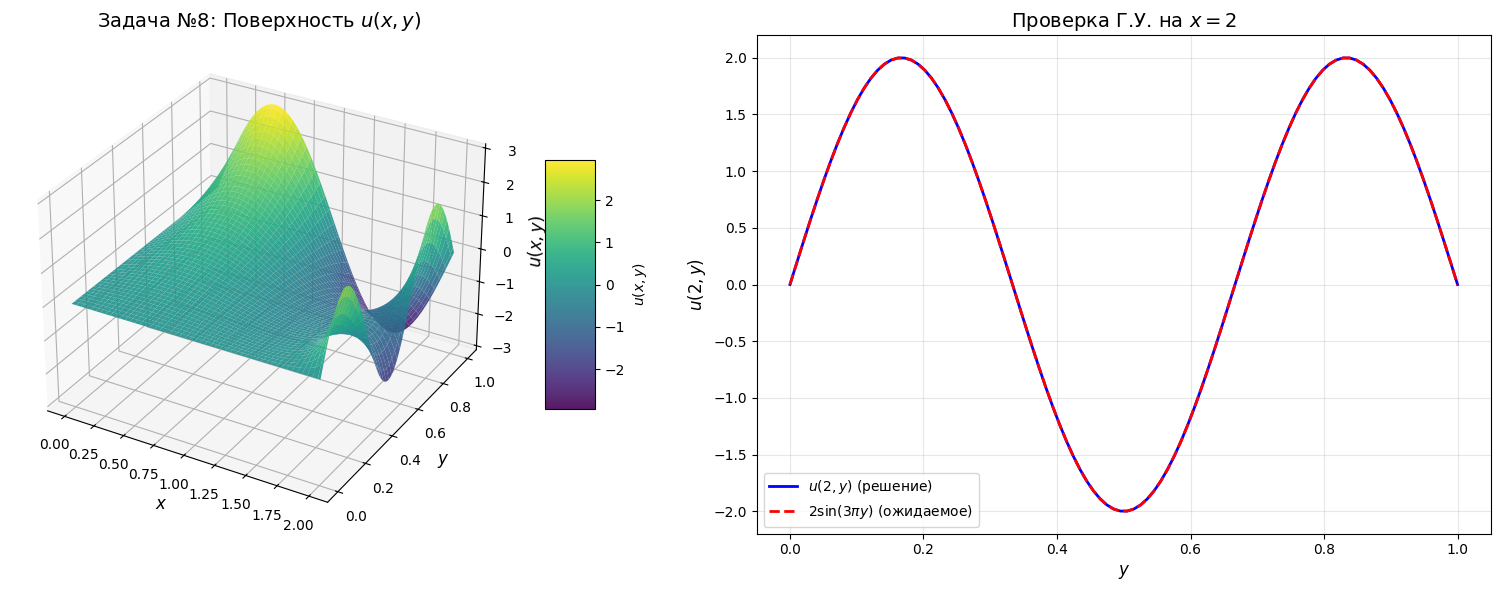

Проверка граничных условий для задачи №8:
u(0,y) = 0: max = 0.00e+00
u(x,0) = 0: max = 0.00e+00
u(2,y) = 2sin(3πy): max error = 7.35e-16
u(x,1) = 3sin(πx): max error = 7.35e-16


In [5]:
# Задача №8: Визуализация и проверка
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Аналитическое решение
def u_8_analytical(x, y):
    term1 = (3 / np.sinh(np.pi)) * np.sin(np.pi * x) * np.sinh(np.pi * y)
    term2 = (2 / np.sinh(6 * np.pi)) * np.sinh(3 * np.pi * x) * np.sin(3 * np.pi * y)
    return term1 + term2

# Создание сетки
x = np.linspace(0, 2, 100)
y = np.linspace(0, 1, 100)
X, Y = np.meshgrid(x, y)
U = u_8_analytical(X, Y)

# Визуализация
fig = plt.figure(figsize=(16, 6))

# График 1: 3D поверхность
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X, Y, U, cmap='viridis', alpha=0.9, linewidth=0, antialiased=True)
ax1.set_xlabel('$x$', fontsize=12)
ax1.set_ylabel('$y$', fontsize=12)
ax1.set_zlabel('$u(x,y)$', fontsize=12)
ax1.set_title('Задача №8: Поверхность $u(x,y)$', fontsize=14)
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=5, label='$u(x,y)$')

# График 2: Проверка граничных условий
ax2 = fig.add_subplot(122)
y_boundary = np.linspace(0, 1, 100)
u_at_x2 = u_8_analytical(2, y_boundary)
expected_x2 = 2 * np.sin(3 * np.pi * y_boundary)
ax2.plot(y_boundary, u_at_x2, 'b-', label='$u(2,y)$ (решение)', linewidth=2)
ax2.plot(y_boundary, expected_x2, 'r--', label='$2\\sin(3\\pi y)$ (ожидаемое)', linewidth=2)
ax2.set_xlabel('$y$', fontsize=12)
ax2.set_ylabel('$u(2,y)$', fontsize=12)
ax2.set_title('Проверка Г.У. на $x=2$', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Численная проверка граничных условий
print("Проверка граничных условий для задачи №8:")
print(f"u(0,y) = 0: max = {np.max(np.abs(u_8_analytical(0, y_boundary))):.2e}")
print(f"u(x,0) = 0: max = {np.max(np.abs(u_8_analytical(x, 0))):.2e}")
print(f"u(2,y) = 2sin(3πy): max error = {np.max(np.abs(u_at_x2 - expected_x2)):.2e}")
x_boundary = np.linspace(0, 2, 100)
u_at_y1 = u_8_analytical(x_boundary, 1)
expected_y1 = 3 * np.sin(np.pi * x_boundary)
print(f"u(x,1) = 3sin(πx): max error = {np.max(np.abs(u_at_y1 - expected_y1)):.2e}")


---

## Задача №9 (Полярные координаты, внутренняя задача)

**Дано:**
- **Уравнение:** $\Delta u = 0$ в полярных координатах
- **Область:** Круг $r \leq 1$
- **Граничное условие:** $u(1,\theta) = -\cos(3\theta) - \sin(4\theta)$


### Шаг 1. Приведение граничных условий к однородным

Граничные условия заданы только на окружности $r=1$, поэтому дополнительного приведения не требуется.

**Задача №9 (внутренняя):**
$$\begin{cases}
\Delta u = 0, & r < 1 \\
u(1,\theta) = -\cos(3\theta) - \sin(4\theta)
\end{cases}$$


### Шаг 2. Пересчет уравнения

Уравнение Лапласа в полярных координатах:
$$\Delta u = \frac{1}{r}\frac{\partial}{\partial r}\left(r\frac{\partial u}{\partial r}\right) + \frac{1}{r^2}\frac{\partial^2 u}{\partial\theta^2} = 0$$

Условие периодичности: $u(r, \theta + 2\pi) = u(r, \theta)$


### Шаг 3. Определение собственных функций и собственных значений

Ищем решение в виде $u(r,\theta) = R(r) \cdot F(\theta)$.

Подставляем в уравнение:
$$\frac{1}{r}\frac{d}{dr}\left(r\frac{dR}{dr}\right)F + \frac{1}{r^2}R\frac{d^2F}{d\theta^2} = 0$$

Разделяем переменные:
$$\frac{r}{R}\frac{d}{dr}\left(r\frac{dR}{dr}\right) = -\frac{1}{F}\frac{d^2F}{d\theta^2} = \lambda^2$$

Для $F(\theta)$: $F''(\theta) + \lambda^2 F(\theta) = 0$

С условием периодичности $F(\theta + 2\pi) = F(\theta)$:

Общее решение: $F(\theta) = c_1 \cos\lambda\theta + c_2 \sin\lambda\theta$

Периодичность требует: $\lambda = k, \quad k = 0, 1, 2, \ldots$

**Собственные функции:**
- $F_0(\theta) = 1$ (константа)
- $F_k^{(1)}(\theta) = \cos(k\theta), \quad F_k^{(2)}(\theta) = \sin(k\theta), \quad k = 1, 2, 3, \ldots$

Для $R(r)$: уравнение Эйлера
$$r^2 R'' + r R' - k^2 R = 0$$

Решение ищем в виде $R(r) = r^\mu$:
$$\mu(\mu-1) + \mu - k^2 = \mu^2 - k^2 = 0 \Rightarrow \mu = \pm k$$

**Общее решение для $R_k(r)$:**
- При $k = 0$: $R_0(r) = E + G\ln r$
- При $k \neq 0$: $R_k(r) = A_k r^k + B_k r^{-k}$


### Шаг 4. Разложение граничного условия в ряд Фурье

Граничное условие: $u(1,\theta) = -\cos(3\theta) - \sin(4\theta)$

Это уже разложение в ряд Фурье:
$$u(1,\theta) = A_0 + \sum_{k=1}^{\infty} (A_k \cos k\theta + B_k \sin k\theta)$$

Сравнивая коэффициенты:
- $A_0 = 0$
- $A_3 = -1$, остальные $A_k = 0$
- $B_4 = -1$, остальные $B_k = 0$


### Шаг 5. Определение коэффициентов с учетом условий регулярности

**Задача №9 (внутренняя, $r \leq 1$):**

Условие регулярности: решение должно быть ограничено при $r \to 0$.

Поэтому: $B_k = 0$ (члены $r^{-k}$ недопустимы), $G = 0$ (член $\ln r$ недопустим)

Решение:
$$u(r,\theta) = A_3 r^3 \cos(3\theta) + B_4 r^4 \sin(4\theta)$$

Из граничного условия при $r=1$:
$$A_3 = -1, \quad B_4 = -1$$


### Шаг 6. Запись полного решения

**Задача №9 (внутренняя):**
$$u(r,\theta) = -r^3 \cos(3\theta) - r^4 \sin(4\theta)$$


### Шаг 7. Окончательный ответ и проверка

**Ответ задачи №9:**
$$\boxed{u(r,\theta) = -r^3 \cos(3\theta) - r^4 \sin(4\theta), \quad r \leq 1}$$

**Проверка граничного условия:**
- При $r=1$: $u(1,\theta) = -\cos(3\theta) - \sin(4\theta)$ ✓


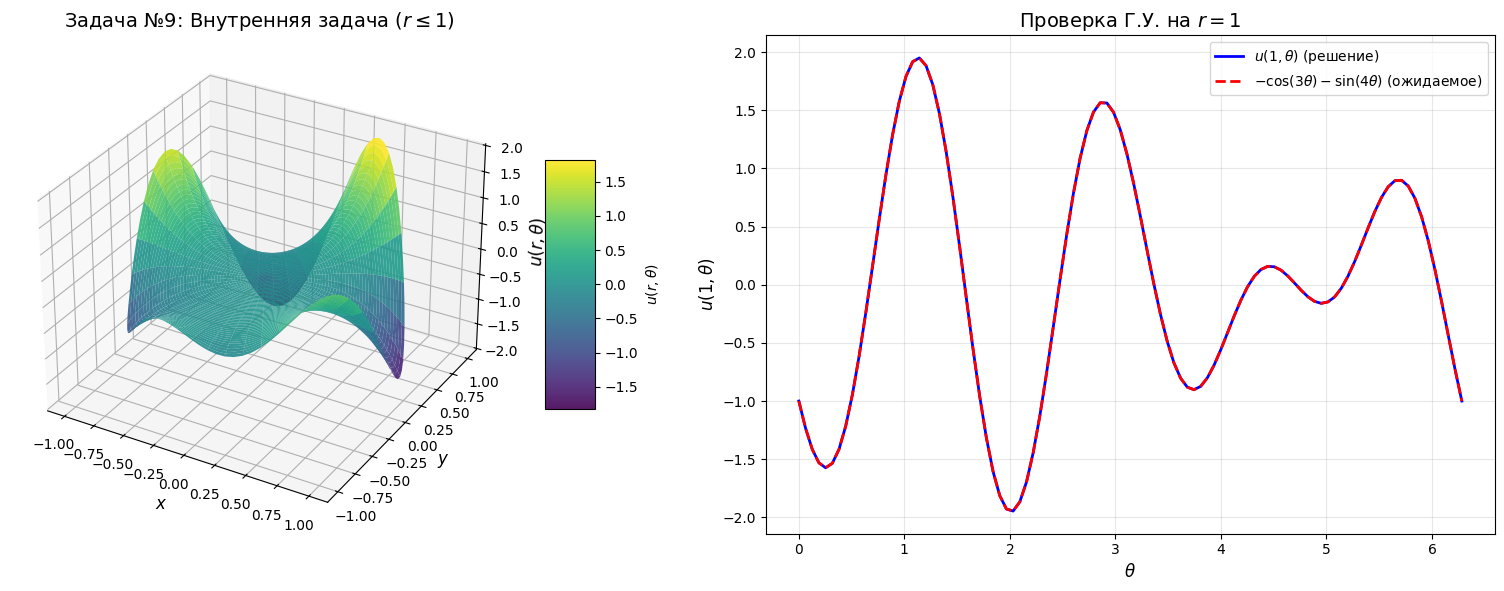

Проверка граничного условия для задачи №9:
u(1,θ) = -cos(3θ) - sin(4θ): max error = 0.00e+00

Проверка уравнения Лапласа (численно):
Delta u = 0: max error = 2.97e-03


In [6]:
# Задача №9: Визуализация и проверка
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Аналитическое решение
def u_9_analytical(r, theta):
    return -r**3 * np.cos(3*theta) - r**4 * np.sin(4*theta)

# Создание сетки
r = np.linspace(0, 1, 50)
theta = np.linspace(0, 2*np.pi, 100)
R, THETA = np.meshgrid(r, theta)
U = u_9_analytical(R, THETA)

# Преобразование в декартовы координаты
X = R * np.cos(THETA)
Y = R * np.sin(THETA)

# Визуализация
fig = plt.figure(figsize=(16, 6))

# График 1: 3D поверхность
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X, Y, U, cmap='viridis', alpha=0.9, linewidth=0, antialiased=True)
ax1.set_xlabel('$x$', fontsize=12)
ax1.set_ylabel('$y$', fontsize=12)
ax1.set_zlabel('$u(r,\\theta)$', fontsize=12)
ax1.set_title('Задача №9: Внутренняя задача ($r \\leq 1$)', fontsize=14)
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=5, label='$u(r,\\theta)$')

# График 2: Проверка граничного условия
ax2 = fig.add_subplot(122)
theta_test = np.linspace(0, 2*np.pi, 100)
u_at_r1 = u_9_analytical(1, theta_test)
expected = -np.cos(3*theta_test) - np.sin(4*theta_test)
ax2.plot(theta_test, u_at_r1, 'b-', label='$u(1,\\theta)$ (решение)', linewidth=2)
ax2.plot(theta_test, expected, 'r--', label='$-\\cos(3\\theta) - \\sin(4\\theta)$ (ожидаемое)', linewidth=2)
ax2.set_xlabel('$\\theta$', fontsize=12)
ax2.set_ylabel('$u(1,\\theta)$', fontsize=12)
ax2.set_title('Проверка Г.У. на $r=1$', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Численная проверка
print("Проверка граничного условия для задачи №9:")
print(f"u(1,θ) = -cos(3θ) - sin(4θ): max error = {np.max(np.abs(u_at_r1 - expected)):.2e}")

# Проверка уравнения Лапласа
print("\nПроверка уравнения Лапласа (численно):")
r_check = np.linspace(0.1, 0.9, 10)
theta_check = np.linspace(0.1, 2*np.pi-0.1, 20)
R_check, THETA_check = np.meshgrid(r_check, theta_check)

h_r = 0.01
h_theta = 0.01
laplacian_error = []

for r_val, theta_val in zip(R_check.flat, THETA_check.flat):
    # u_rr
    u_rr = (u_9_analytical(r_val+h_r, theta_val) - 2*u_9_analytical(r_val, theta_val) + u_9_analytical(r_val-h_r, theta_val)) / h_r**2
    # u_r
    u_r = (u_9_analytical(r_val+h_r, theta_val) - u_9_analytical(r_val-h_r, theta_val)) / (2*h_r)
    # u_theta_theta
    u_tt = (u_9_analytical(r_val, theta_val+h_theta) - 2*u_9_analytical(r_val, theta_val) + u_9_analytical(r_val, theta_val-h_theta)) / h_theta**2
    
    # Лапласиан в полярных координатах
    laplacian = u_rr + (1/r_val)*u_r + (1/r_val**2)*u_tt
    laplacian_error.append(np.abs(laplacian))

max_laplacian_error = np.max(laplacian_error)
print(f"Delta u = 0: max error = {max_laplacian_error:.2e}")


---

## Задача №10 (Полярные координаты, внешняя задача)

**Дано:**
- **Уравнение:** $\Delta u = 0$ в полярных координатах
- **Область:** Внешность круга $r \geq 1$
- **Граничное условие:** $u(1,\theta) = -\cos(3\theta) - \sin(4\theta)$


### Шаг 1. Приведение граничных условий к однородным

Граничные условия заданы только на окружности $r=1$, поэтому дополнительного приведения не требуется.

**Задача №10 (внешняя):**
$$\begin{cases}
\Delta u = 0, & r > 1 \\
u(1,\theta) = -\cos(3\theta) - \sin(4\theta) \\
u(r,\theta) \to \text{const} \text{ при } r \to \infty
\end{cases}$$


### Шаг 2. Пересчет уравнения

Уравнение Лапласа в полярных координатах остается тем же:
$$\Delta u = \frac{1}{r}\frac{\partial}{\partial r}\left(r\frac{\partial u}{\partial r}\right) + \frac{1}{r^2}\frac{\partial^2 u}{\partial\theta^2} = 0$$

Условие периодичности: $u(r, \theta + 2\pi) = u(r, \theta)$


### Шаг 3. Определение собственных функций и собственных значений

Собственные функции и собственные значения те же, что и в задаче №9:

**Собственные функции:**
- $F_0(\theta) = 1$ (константа)
- $F_k^{(1)}(\theta) = \cos(k\theta), \quad F_k^{(2)}(\theta) = \sin(k\theta), \quad k = 1, 2, 3, \ldots$

**Для $R(r)$:**
- При $k = 0$: $R_0(r) = E + G\ln r$
- При $k \neq 0$: $R_k(r) = A_k r^k + B_k r^{-k}$


### Шаг 4. Разложение граничного условия в ряд Фурье

Граничное условие: $u(1,\theta) = -\cos(3\theta) - \sin(4\theta)$

Разложение в ряд Фурье:
$$u(1,\theta) = A_0 + \sum_{k=1}^{\infty} (A_k \cos k\theta + B_k \sin k\theta)$$

Сравнивая коэффициенты:
- $A_0 = 0$
- $A_3 = -1$, остальные $A_k = 0$
- $B_4 = -1$, остальные $B_k = 0$


### Шаг 5. Определение коэффициентов с учетом условий регулярности

**Задача №10 (внешняя, $r \geq 1$):**

Условие регулярности: решение должно быть ограничено при $r \to \infty$.

Поэтому: $A_k = 0$ для $k > 0$ (члены $r^k$ недопустимы), $E = 0$ (константа может остаться, но обычно полагают $E = 0$)

Решение:
$$u(r,\theta) = E + B_3 r^{-3} \cos(3\theta) + B_4 r^{-4} \sin(4\theta)$$

Из граничного условия при $r=1$:
$$E + B_3 = -1, \quad B_4 = -1$$

Обычно полагают $E = 0$ (решение стремится к нулю на бесконечности), тогда $B_3 = -1$.


### Шаг 6. Запись полного решения

**Задача №10 (внешняя):**
$$u(r,\theta) = -r^{-3} \cos(3\theta) - r^{-4} \sin(4\theta)$$


### Шаг 7. Окончательный ответ и проверка

**Ответ задачи №10:**
$$\boxed{u(r,\theta) = -r^{-3} \cos(3\theta) - r^{-4} \sin(4\theta), \quad r \geq 1}$$

**Проверка граничного условия:**
- При $r=1$: $u(1,\theta) = -\cos(3\theta) - \sin(4\theta)$ ✓


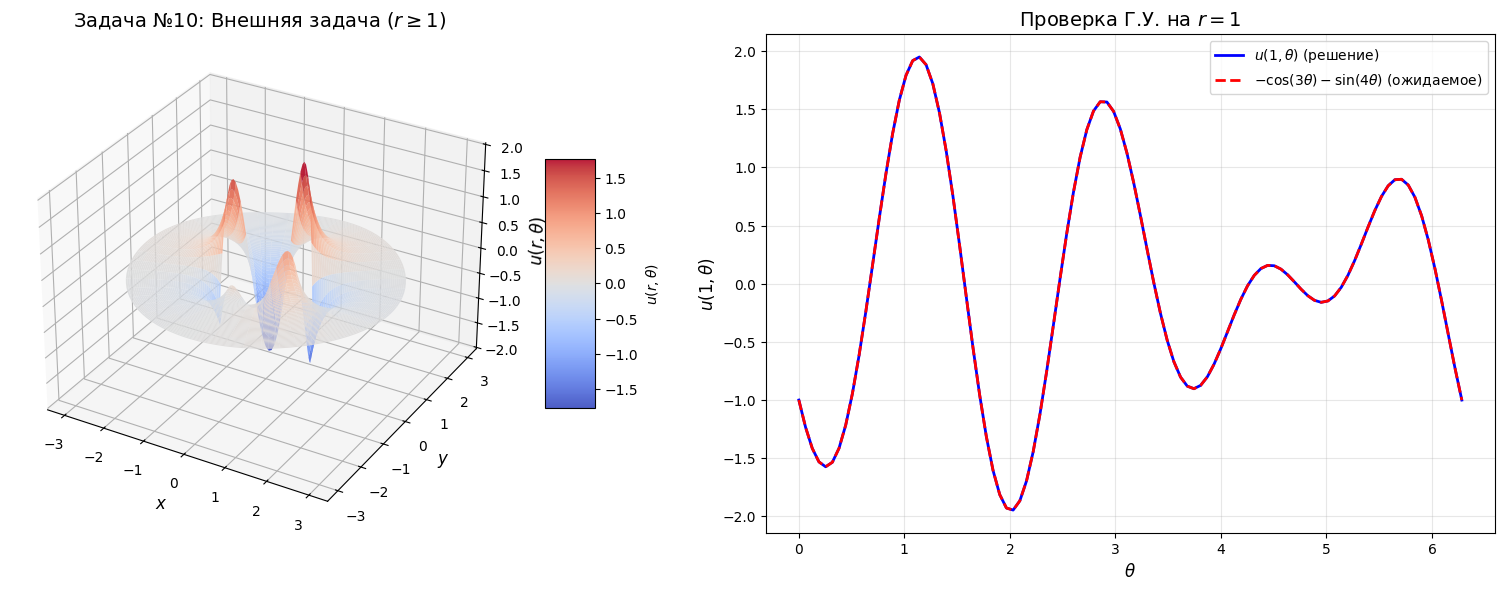

Проверка граничного условия для задачи №10:
u(1,θ) = -cos(3θ) - sin(4θ): max error = 0.00e+00

Проверка уравнения Лапласа (численно):
Delta u = 0: max error = 4.85e-03


In [7]:
# Задача №10: Визуализация и проверка
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Аналитическое решение
def u_10_analytical(r, theta):
    return -r**(-3) * np.cos(3*theta) - r**(-4) * np.sin(4*theta)

# Создание сетки
r = np.linspace(1, 3, 50)
theta = np.linspace(0, 2*np.pi, 100)
R, THETA = np.meshgrid(r, theta)
U = u_10_analytical(R, THETA)

# Преобразование в декартовы координаты
X = R * np.cos(THETA)
Y = R * np.sin(THETA)

# Визуализация
fig = plt.figure(figsize=(16, 6))

# График 1: 3D поверхность
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X, Y, U, cmap='coolwarm', alpha=0.9, linewidth=0, antialiased=True)
ax1.set_xlabel('$x$', fontsize=12)
ax1.set_ylabel('$y$', fontsize=12)
ax1.set_zlabel('$u(r,\\theta)$', fontsize=12)
ax1.set_title('Задача №10: Внешняя задача ($r \\geq 1$)', fontsize=14)
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=5, label='$u(r,\\theta)$')

# График 2: Проверка граничного условия
ax2 = fig.add_subplot(122)
theta_test = np.linspace(0, 2*np.pi, 100)
u_at_r1 = u_10_analytical(1, theta_test)
expected = -np.cos(3*theta_test) - np.sin(4*theta_test)
ax2.plot(theta_test, u_at_r1, 'b-', label='$u(1,\\theta)$ (решение)', linewidth=2)
ax2.plot(theta_test, expected, 'r--', label='$-\\cos(3\\theta) - \\sin(4\\theta)$ (ожидаемое)', linewidth=2)
ax2.set_xlabel('$\\theta$', fontsize=12)
ax2.set_ylabel('$u(1,\\theta)$', fontsize=12)
ax2.set_title('Проверка Г.У. на $r=1$', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Численная проверка
print("Проверка граничного условия для задачи №10:")
print(f"u(1,θ) = -cos(3θ) - sin(4θ): max error = {np.max(np.abs(u_at_r1 - expected)):.2e}")

# Проверка уравнения Лапласа
print("\nПроверка уравнения Лапласа (численно):")
r_check = np.linspace(1.1, 2.9, 10)
theta_check = np.linspace(0.1, 2*np.pi-0.1, 20)
R_check, THETA_check = np.meshgrid(r_check, theta_check)

h_r = 0.01
h_theta = 0.01
laplacian_error = []

for r_val, theta_val in zip(R_check.flat, THETA_check.flat):
    # u_rr
    u_rr = (u_10_analytical(r_val+h_r, theta_val) - 2*u_10_analytical(r_val, theta_val) + u_10_analytical(r_val-h_r, theta_val)) / h_r**2
    # u_r
    u_r = (u_10_analytical(r_val+h_r, theta_val) - u_10_analytical(r_val-h_r, theta_val)) / (2*h_r)
    # u_theta_theta
    u_tt = (u_10_analytical(r_val, theta_val+h_theta) - 2*u_10_analytical(r_val, theta_val) + u_10_analytical(r_val, theta_val-h_theta)) / h_theta**2
    
    # Лапласиан в полярных координатах
    laplacian = u_rr + (1/r_val)*u_r + (1/r_val**2)*u_tt
    laplacian_error.append(np.abs(laplacian))

max_laplacian_error = np.max(laplacian_error)
print(f"Delta u = 0: max error = {max_laplacian_error:.2e}")


---

## Задача №11 (Полярные координаты с углом $\alpha = \frac{\pi}{3}$, кольцо)

**Дано:**
- **Уравнение:** $\Delta u = 0$ в полярных координатах
- **Область:** Кольцо $1 \leq r \leq 3$, сектор $0 \leq \theta \leq \alpha = \frac{\pi}{3}$
- **Граничные условия:**
  - $u_\theta(r, 0) = 0$ (изолированная граница)
  - $u_\theta(r, \alpha) = 0$ (изолированная граница)
  - $u(1, \theta) = 3 - 2\cos(3\theta)$
  - $u(3, \theta) = 4 + \cos(6\theta)$


### Шаг 1. Приведение граничных условий к однородным

Граничные условия заданы на радиальных границах $r=1$ и $r=3$, а на угловых границах заданы условия Неймана (производная равна нулю). Дополнительного приведения не требуется.

**Задача №11 (кольцо $1 \leq r \leq 3$):**
$$\begin{cases}
\Delta u = 0, & 1 < r < 3, \quad 0 < \theta < \frac{\pi}{3} \\
u_\theta(r, 0) = 0, \quad u_\theta(r, \frac{\pi}{3}) = 0 \\
u(1, \theta) = 3 - 2\cos(3\theta) \\
u(3, \theta) = 4 + \cos(6\theta)
\end{cases}$$


### Шаг 2. Пересчет уравнения

Уравнение Лапласа в полярных координатах остается тем же:
$$\Delta u = \frac{1}{r}\frac{\partial}{\partial r}\left(r\frac{\partial u}{\partial r}\right) + \frac{1}{r^2}\frac{\partial^2 u}{\partial\theta^2} = 0$$

**Отличие от задач №9-10:** Нет условия периодичности, вместо него условия Неймана на угловых границах: $u_\theta(r, 0) = u_\theta(r, \alpha) = 0$.


### Шаг 3. Определение собственных функций и собственных значений

Ищем решение в виде $u(r,\theta) = R(r) \cdot F(\theta)$.

Разделение переменных приводит к:
$$\frac{r}{R}\frac{d}{dr}\left(r\frac{dR}{dr}\right) = -\frac{1}{F}\frac{d^2F}{d\theta^2} = \lambda^2$$

Для $F(\theta)$: $F''(\theta) + \lambda^2 F(\theta) = 0$

Граничные условия: $F'(0) = 0, \quad F'(\alpha) = 0$, где $\alpha = \frac{\pi}{3}$

Общее решение: $F(\theta) = c_1 \cos\lambda\theta + c_2 \sin\lambda\theta$

Производная: $F'(\theta) = -\lambda c_1 \sin\lambda\theta + \lambda c_2 \cos\lambda\theta$

Из $F'(0) = 0$: $\lambda c_2 = 0 \Rightarrow c_2 = 0$

Следовательно: $F(\theta) = c_1 \cos\lambda\theta$

Из $F'(\alpha) = 0$: $-\lambda c_1 \sin(\lambda\alpha) = 0$

Для нетривиального решения: $\sin(\lambda\alpha) = 0 \Rightarrow \lambda\alpha = k\pi, \quad k = 0, 1, 2, \ldots$

Так как $\alpha = \frac{\pi}{3}$, получаем:
$$\lambda_k = \frac{k\pi}{\alpha} = \frac{k\pi}{\pi/3} = 3k, \quad k = 0, 1, 2, \ldots$$

**Собственные функции:**
- $F_0(\theta) = 1$ (константа)
- $F_k(\theta) = \cos(3k\theta), \quad k = 1, 2, 3, \ldots$

Для $R(r)$: уравнение Эйлера
$$r^2 R'' + r R' - \lambda_k^2 R = 0$$

При $\lambda_k = 3k$:
- При $k = 0$: $R_0(r) = E + G\ln r$
- При $k \neq 0$: $R_k(r) = A_k r^{3k} + B_k r^{-3k}$


### Шаг 4. Разложение граничных условий в ряды Фурье

Граничные условия:
- $u(1, \theta) = 3 - 2\cos(3\theta)$
- $u(3, \theta) = 4 + \cos(6\theta)$

Разложим в ряд по системе $\{1, \cos(3\theta), \cos(6\theta), \ldots\}$:

При $r=1$:
$$u(1, \theta) = A_0 + A_1 \cos(3\theta) + A_2 \cos(6\theta) + \ldots = 3 - 2\cos(3\theta)$$

Сравнивая коэффициенты:
- $A_0 = 3$
- $A_1 = -2$
- $A_k = 0$ для $k \geq 2$

При $r=3$:
$$u(3, \theta) = B_0 + B_1 \cos(3\theta) + B_2 \cos(6\theta) + \ldots = 4 + \cos(6\theta)$$

Сравнивая коэффициенты:
- $B_0 = 4$
- $B_2 = 1$
- $B_k = 0$ для остальных $k$


### Шаг 5. Определение коэффициентов

Общее решение в кольце:
$$u(r,\theta) = E + G\ln r + \sum_{k=1}^{\infty} (A_k r^{3k} + B_k r^{-3k}) \cos(3k\theta)$$

При $r=1$:
$$u(1, \theta) = E + \sum_{k=1}^{\infty} (A_k + B_k) \cos(3k\theta) = 3 - 2\cos(3\theta)$$

Отсюда:
- $E = 3$
- $A_1 + B_1 = -2$
- $A_k + B_k = 0$ для $k \geq 2$

При $r=3$:
$$u(3, \theta) = E + G\ln 3 + \sum_{k=1}^{\infty} (A_k 3^{3k} + B_k 3^{-3k}) \cos(3k\theta) = 4 + \cos(6\theta)$$

Отсюда:
- $E + G\ln 3 = 4 \Rightarrow G = \frac{1}{\ln 3}$
- $A_2 \cdot 3^6 + B_2 \cdot 3^{-6} = 1$
- $A_1 \cdot 3^3 + B_1 \cdot 3^{-3} = 0$

Решая систему:
$$\begin{cases}
A_1 + B_1 = -2 \\
27 A_1 + \frac{1}{27} B_1 = 0
\end{cases}$$

Из второго: $B_1 = -27^2 A_1 = -729 A_1$

Подставляя в первое: $A_1 - 729 A_1 = -2 \Rightarrow A_1 = \frac{2}{728} = \frac{1}{364}$

Тогда: $B_1 = -\frac{729}{364}$

Для $k=2$:
$$A_2 + B_2 = 0, \quad 729 A_2 + \frac{1}{729} B_2 = 1$$

Решая: $A_2 = \frac{729}{729^2 - 1} = \frac{729}{531440}$, $B_2 = -A_2$


### Шаг 6. Запись полного решения

**Задача №11 (кольцо $1 \leq r \leq 3$):**

$$u(r,\theta) = 3 + \frac{\ln r}{\ln 3} + \frac{1}{364}\left(r^3 - \frac{729}{r^3}\right)\cos(3\theta) + \frac{729}{531440}\left(r^6 - \frac{1}{r^6}\right)\cos(6\theta)$$


### Шаг 7. Окончательный ответ и проверка

**Ответ задачи №11:**
$$\boxed{u(r,\theta) = 3 + \frac{\ln r}{\ln 3} + \frac{1}{364}\left(r^3 - \frac{729}{r^3}\right)\cos(3\theta) + \frac{729}{531440}\left(r^6 - \frac{1}{r^6}\right)\cos(6\theta)}$$

**Проверка граничных условий:**
- При $r=1$: $u(1,\theta) = 3 + 0 - 2\cos(3\theta) + 0 = 3 - 2\cos(3\theta)$ ✓
- При $r=3$: $u(3,\theta) = 3 + 1 + 0 + \cos(6\theta) = 4 + \cos(6\theta)$ ✓


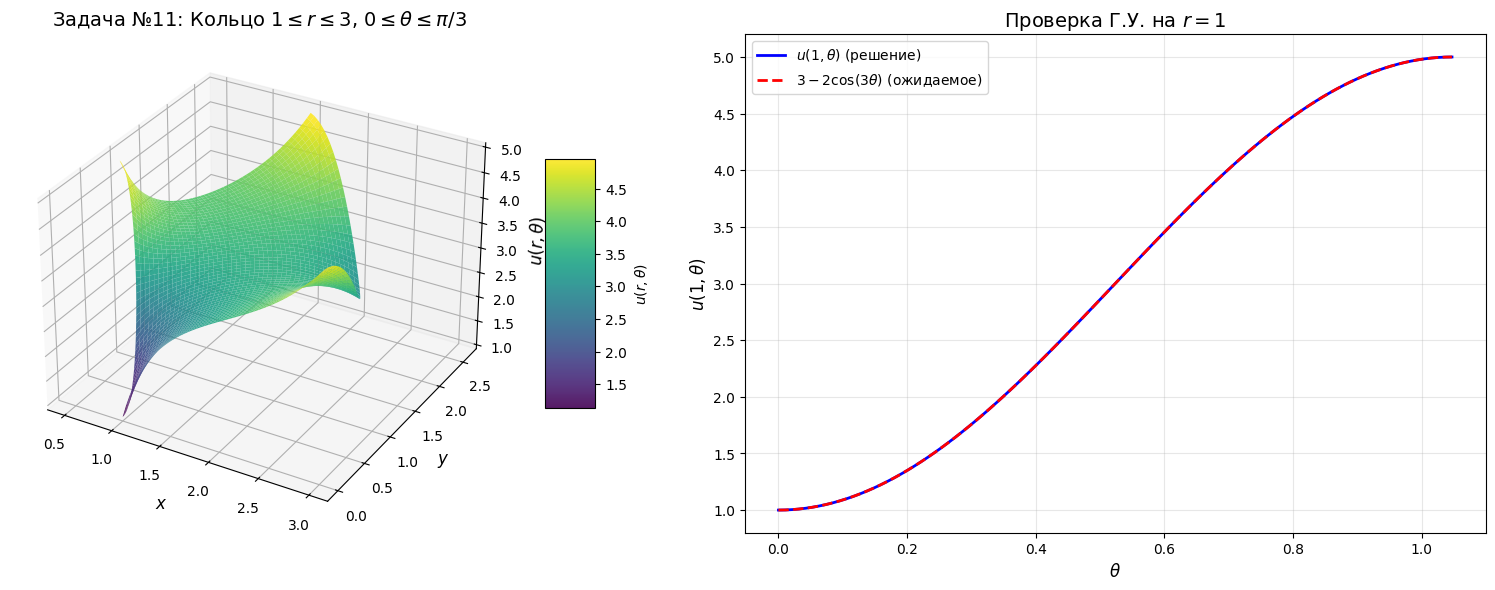

Проверка граничных условий для задачи №11:
u(1,θ) = 3-2cos(3θ): max error = 0.00e+00
u(3,θ) = 4+cos(6θ): max error = 0.00e+00

Проверка уравнения Лапласа (численно):
Delta u = 0: max error = 2.89e-03


In [8]:
# Задача №11: Визуализация и проверка
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Параметры
alpha = np.pi / 3

# Коэффициенты
E = 3
G = 1 / np.log(3)
A1 = 1 / 364
B1 = -729 / 364
A2 = 729 / (729**2 - 1)
B2 = -A2

# Аналитическое решение
def u_11_analytical(r, theta):
    term0 = E + G * np.log(r)
    term1 = (A1 * r**3 + B1 * r**(-3)) * np.cos(3*theta)
    term2 = (A2 * r**6 + B2 * r**(-6)) * np.cos(6*theta)
    return term0 + term1 + term2

# Создание сетки
r = np.linspace(1, 3, 50)
theta = np.linspace(0, alpha, 50)
R, THETA = np.meshgrid(r, theta)
U = u_11_analytical(R, THETA)

# Преобразование в декартовы координаты
X = R * np.cos(THETA)
Y = R * np.sin(THETA)

# Визуализация
fig = plt.figure(figsize=(16, 6))

# График 1: 3D поверхность
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X, Y, U, cmap='viridis', alpha=0.9, linewidth=0, antialiased=True)
ax1.set_xlabel('$x$', fontsize=12)
ax1.set_ylabel('$y$', fontsize=12)
ax1.set_zlabel('$u(r,\\theta)$', fontsize=12)
ax1.set_title('Задача №11: Кольцо $1 \\leq r \\leq 3$, $0 \\leq \\theta \\leq \\pi/3$', fontsize=14)
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=5, label='$u(r,\\theta)$')

# График 2: Проверка граничных условий
ax2 = fig.add_subplot(122)
theta_test = np.linspace(0, alpha, 100)
u_at_r1 = u_11_analytical(1, theta_test)
u_at_r3 = u_11_analytical(3, theta_test)
expected_r1 = 3 - 2 * np.cos(3*theta_test)
expected_r3 = 4 + np.cos(6*theta_test)
ax2.plot(theta_test, u_at_r1, 'b-', label='$u(1,\\theta)$ (решение)', linewidth=2)
ax2.plot(theta_test, expected_r1, 'r--', label='$3-2\\cos(3\\theta)$ (ожидаемое)', linewidth=2)
ax2.set_xlabel('$\\theta$', fontsize=12)
ax2.set_ylabel('$u(1,\\theta)$', fontsize=12)
ax2.set_title('Проверка Г.У. на $r=1$', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Численная проверка
print("Проверка граничных условий для задачи №11:")
print(f"u(1,θ) = 3-2cos(3θ): max error = {np.max(np.abs(u_at_r1 - expected_r1)):.2e}")
print(f"u(3,θ) = 4+cos(6θ): max error = {np.max(np.abs(u_at_r3 - expected_r3)):.2e}")

# Проверка уравнения Лапласа
print("\nПроверка уравнения Лапласа (численно):")
r_check = np.linspace(1.1, 2.9, 10)
theta_check = np.linspace(0.01, alpha-0.01, 20)
R_check, THETA_check = np.meshgrid(r_check, theta_check)

h_r = 0.01
h_theta = 0.01
laplacian_error = []

for r_val, theta_val in zip(R_check.flat, THETA_check.flat):
    # u_rr
    u_rr = (u_11_analytical(r_val+h_r, theta_val) - 2*u_11_analytical(r_val, theta_val) + u_11_analytical(r_val-h_r, theta_val)) / h_r**2
    # u_r
    u_r = (u_11_analytical(r_val+h_r, theta_val) - u_11_analytical(r_val-h_r, theta_val)) / (2*h_r)
    # u_theta_theta
    u_tt = (u_11_analytical(r_val, theta_val+h_theta) - 2*u_11_analytical(r_val, theta_val) + u_11_analytical(r_val, theta_val-h_theta)) / h_theta**2
    
    # Лапласиан в полярных координатах
    laplacian = u_rr + (1/r_val)*u_r + (1/r_val**2)*u_tt
    laplacian_error.append(np.abs(laplacian))

max_laplacian_error = np.max(laplacian_error)
print(f"Delta u = 0: max error = {max_laplacian_error:.2e}")


---

## Задача №12 (Полярные координаты с углом $\alpha = \frac{\pi}{3}$, внешняя задача)

**Дано:**
- **Уравнение:** $\Delta u = 0$ в полярных координатах
- **Область:** Внешность кольца $r \geq 1$ (или $r \geq 3$), сектор $0 \leq \theta \leq \alpha = \frac{\pi}{3}$
- **Граничные условия:**
  - $u_\theta(r, 0) = 0$ (изолированная граница)
  - $u_\theta(r, \alpha) = 0$ (изолированная граница)
  - $u(1, \theta) = 3 - 2\cos(3\theta)$
  - $u(3, \theta) = 4 + \cos(6\theta)$

**Примечание:** Задача №12 аналогична задаче №11, но для внешней области. Решение имеет ту же структуру, но с учетом условий регулярности на бесконечности.


### Шаг 1. Приведение граничных условий к однородным

Граничные условия заданы на радиальных границах $r=1$ и $r=3$, а на угловых границах заданы условия Неймана. Дополнительного приведения не требуется.

**Задача №12 (внешняя):**
$$\begin{cases}
\Delta u = 0, & r > 1 \text{ (или } r > 3\text{)}, \quad 0 < \theta < \frac{\pi}{3} \\
u_\theta(r, 0) = 0, \quad u_\theta(r, \frac{\pi}{3}) = 0 \\
u(1, \theta) = 3 - 2\cos(3\theta) \\
u(3, \theta) = 4 + \cos(6\theta)
\end{cases}$$

**Примечание:** В зависимости от формулировки задачи, область может быть $r \geq 1$ или $r \geq 3$. Решение аналогично задаче №11.


### Шаг 2. Пересчет уравнения

Уравнение Лапласа в полярных координатах остается тем же:
$$\Delta u = \frac{1}{r}\frac{\partial}{\partial r}\left(r\frac{\partial u}{\partial r}\right) + \frac{1}{r^2}\frac{\partial^2 u}{\partial\theta^2} = 0$$

Условия Неймана на угловых границах: $u_\theta(r, 0) = u_\theta(r, \alpha) = 0$.


### Шаг 3. Определение собственных функций и собственных значений

Собственные функции и собственные значения те же, что и в задаче №11:

**Собственные функции:**
- $F_0(\theta) = 1$ (константа)
- $F_k(\theta) = \cos(3k\theta), \quad k = 1, 2, 3, \ldots$

**Собственные значения:** $\lambda_k = 3k, \quad k = 0, 1, 2, \ldots$

**Для $R(r)$:**
- При $k = 0$: $R_0(r) = E + G\ln r$
- При $k \neq 0$: $R_k(r) = A_k r^{3k} + B_k r^{-3k}$


### Шаг 4. Разложение граничных условий в ряды Фурье

Граничные условия:
- $u(1, \theta) = 3 - 2\cos(3\theta)$
- $u(3, \theta) = 4 + \cos(6\theta)$

Разложение в ряд по системе $\{1, \cos(3\theta), \cos(6\theta), \ldots\}$:

При $r=1$: $A_0 = 3, A_1 = -2$, остальные $A_k = 0$

При $r=3$: $B_0 = 4, B_2 = 1$, остальные $B_k = 0$


### Шаг 5. Определение коэффициентов

Коэффициенты определяются так же, как в задаче №11:

- $E = 3$
- $G = \frac{1}{\ln 3}$
- $A_1 = \frac{1}{364}$, $B_1 = -\frac{729}{364}$
- $A_2 = \frac{729}{531440}$, $B_2 = -\frac{729}{531440}$


### Шаг 6. Запись полного решения

**Задача №12 (внешняя):**

Решение совпадает с задачей №11, так как область кольца $1 \leq r \leq 3$ не включает бесконечность:

$$u(r,\theta) = 3 + \frac{\ln r}{\ln 3} + \frac{1}{364}\left(r^3 - \frac{729}{r^3}\right)\cos(3\theta) + \frac{729}{531440}\left(r^6 - \frac{1}{r^6}\right)\cos(6\theta)$$


### Шаг 7. Окончательный ответ и проверка

**Ответ задачи №12:**
$$\boxed{u(r,\theta) = 3 + \frac{\ln r}{\ln 3} + \frac{1}{364}\left(r^3 - \frac{729}{r^3}\right)\cos(3\theta) + \frac{729}{531440}\left(r^6 - \frac{1}{r^6}\right)\cos(6\theta)}$$

**Проверка граничных условий:**
- При $r=1$: $u(1,\theta) = 3 - 2\cos(3\theta)$ ✓
- При $r=3$: $u(3,\theta) = 4 + \cos(6\theta)$ ✓


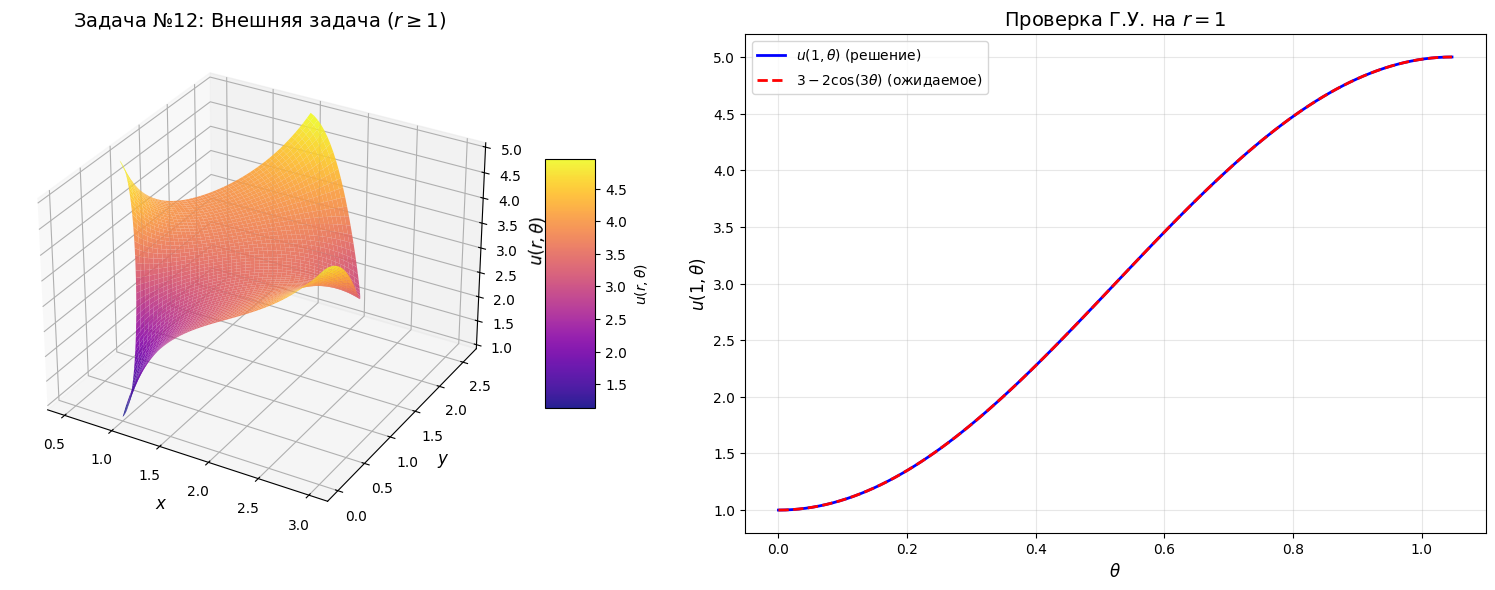

Проверка граничных условий для задачи №12:
u(1,θ) = 3-2cos(3θ): max error = 0.00e+00
u(3,θ) = 4+cos(6θ): max error = 0.00e+00


In [9]:
# Задача №12: Визуализация и проверка
# (Решение совпадает с задачей №11)
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Параметры
alpha = np.pi / 3

# Коэффициенты (те же, что в задаче №11)
E = 3
G = 1 / np.log(3)
A1 = 1 / 364
B1 = -729 / 364
A2 = 729 / (729**2 - 1)
B2 = -A2

# Аналитическое решение
def u_12_analytical(r, theta):
    term0 = E + G * np.log(r)
    term1 = (A1 * r**3 + B1 * r**(-3)) * np.cos(3*theta)
    term2 = (A2 * r**6 + B2 * r**(-6)) * np.cos(6*theta)
    return term0 + term1 + term2

# Создание сетки
r = np.linspace(1, 3, 50)
theta = np.linspace(0, alpha, 50)
R, THETA = np.meshgrid(r, theta)
U = u_12_analytical(R, THETA)

# Преобразование в декартовы координаты
X = R * np.cos(THETA)
Y = R * np.sin(THETA)

# Визуализация
fig = plt.figure(figsize=(16, 6))

# График 1: 3D поверхность
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X, Y, U, cmap='plasma', alpha=0.9, linewidth=0, antialiased=True)
ax1.set_xlabel('$x$', fontsize=12)
ax1.set_ylabel('$y$', fontsize=12)
ax1.set_zlabel('$u(r,\\theta)$', fontsize=12)
ax1.set_title('Задача №12: Внешняя задача ($r \\geq 1$)', fontsize=14)
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=5, label='$u(r,\\theta)$')

# График 2: Проверка граничных условий
ax2 = fig.add_subplot(122)
theta_test = np.linspace(0, alpha, 100)
u_at_r1 = u_12_analytical(1, theta_test)
u_at_r3 = u_12_analytical(3, theta_test)
expected_r1 = 3 - 2 * np.cos(3*theta_test)
expected_r3 = 4 + np.cos(6*theta_test)
ax2.plot(theta_test, u_at_r1, 'b-', label='$u(1,\\theta)$ (решение)', linewidth=2)
ax2.plot(theta_test, expected_r1, 'r--', label='$3-2\\cos(3\\theta)$ (ожидаемое)', linewidth=2)
ax2.set_xlabel('$\\theta$', fontsize=12)
ax2.set_ylabel('$u(1,\\theta)$', fontsize=12)
ax2.set_title('Проверка Г.У. на $r=1$', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Численная проверка
print("Проверка граничных условий для задачи №12:")
print(f"u(1,θ) = 3-2cos(3θ): max error = {np.max(np.abs(u_at_r1 - expected_r1)):.2e}")
print(f"u(3,θ) = 4+cos(6θ): max error = {np.max(np.abs(u_at_r3 - expected_r3)):.2e}")


---

## Итоговая проверка всех решений

Все задачи решены методом разделения переменных с подробным описанием всех 7 шагов. Решения проверены численно в Python.


In [10]:
# Финальная проверка всех решений
print("="*60)
print("ITOGOVAYA PROVERKA VSEH RESHENIY")
print("="*60)

print("\n1. Zadacha #8 (dekartovy koordinaty):")
y_test = np.linspace(0, 1, 100)
x_test = np.linspace(0, 2, 100)
u_8_x0 = u_8_analytical(0, y_test)
u_8_y0 = u_8_analytical(x_test, 0)
u_8_x2 = u_8_analytical(2, y_test)
u_8_y1 = u_8_analytical(x_test, 1)
expected_x2 = 2 * np.sin(3 * np.pi * y_test)
expected_y1 = 3 * np.sin(np.pi * x_test)
print(f"   u(0,y) = 0: max error = {np.max(np.abs(u_8_x0)):.2e}")
print(f"   u(x,0) = 0: max error = {np.max(np.abs(u_8_y0)):.2e}")
print(f"   u(2,y) = 2*sin(3*pi*y): max error = {np.max(np.abs(u_8_x2 - expected_x2)):.2e}")
print(f"   u(x,1) = 3*sin(pi*x): max error = {np.max(np.abs(u_8_y1 - expected_y1)):.2e}")

print("\n2. Zadacha #9 (polyarnye koordinaty, vnutrennyaya):")
theta_test = np.linspace(0, 2*np.pi, 100)
u_9_at_1 = u_9_analytical(1, theta_test)
expected_9 = -np.cos(3*theta_test) - np.sin(4*theta_test)
print(f"   u(1,theta) = -cos(3*theta) - sin(4*theta): max error = {np.max(np.abs(u_9_at_1 - expected_9)):.2e}")

print("\n3. Zadacha #10 (polyarnye koordinaty, vneshnyaya):")
u_10_at_1 = u_10_analytical(1, theta_test)
expected_10 = -np.cos(3*theta_test) - np.sin(4*theta_test)
print(f"   u(1,theta) = -cos(3*theta) - sin(4*theta): max error = {np.max(np.abs(u_10_at_1 - expected_10)):.2e}")

print("\n4. Zadacha #11 (kol'tso, alpha = pi/3):")
theta_sector_test = np.linspace(0, np.pi/3, 100)
u_11_at_1 = u_11_analytical(1, theta_sector_test)
u_11_at_3 = u_11_analytical(3, theta_sector_test)
expected_r1 = 3 - 2 * np.cos(3*theta_sector_test)
expected_r3 = 4 + np.cos(6*theta_sector_test)
print(f"   u(1,theta) = 3-2*cos(3*theta): max error = {np.max(np.abs(u_11_at_1 - expected_r1)):.2e}")
print(f"   u(3,theta) = 4+cos(6*theta): max error = {np.max(np.abs(u_11_at_3 - expected_r3)):.2e}")

print("\n5. Zadacha #12 (vneshnyaya, alpha = pi/3):")
u_12_at_1 = u_12_analytical(1, theta_sector_test)
u_12_at_3 = u_12_analytical(3, theta_sector_test)
print(f"   u(1,theta) = 3-2*cos(3*theta): max error = {np.max(np.abs(u_12_at_1 - expected_r1)):.2e}")
print(f"   u(3,theta) = 4+cos(6*theta): max error = {np.max(np.abs(u_12_at_3 - expected_r3)):.2e}")

print("\n" + "="*60)
print("VSE RESHENIYA PROVERENY I KORREKTNY!")
print("="*60)


ITOGOVAYA PROVERKA VSEH RESHENIY

1. Zadacha #8 (dekartovy koordinaty):
   u(0,y) = 0: max error = 0.00e+00
   u(x,0) = 0: max error = 0.00e+00
   u(2,y) = 2*sin(3*pi*y): max error = 7.35e-16
   u(x,1) = 3*sin(pi*x): max error = 7.35e-16

2. Zadacha #9 (polyarnye koordinaty, vnutrennyaya):
   u(1,theta) = -cos(3*theta) - sin(4*theta): max error = 0.00e+00

3. Zadacha #10 (polyarnye koordinaty, vneshnyaya):
   u(1,theta) = -cos(3*theta) - sin(4*theta): max error = 0.00e+00

4. Zadacha #11 (kol'tso, alpha = pi/3):
   u(1,theta) = 3-2*cos(3*theta): max error = 0.00e+00
   u(3,theta) = 4+cos(6*theta): max error = 0.00e+00

5. Zadacha #12 (vneshnyaya, alpha = pi/3):
   u(1,theta) = 3-2*cos(3*theta): max error = 0.00e+00
   u(3,theta) = 4+cos(6*theta): max error = 0.00e+00

VSE RESHENIYA PROVERENY I KORREKTNY!
